# Test NCRA command to ensure it is averaging in the same way

since I have TBs of data and I don't need to upload it all to zenodo, save just the time mean of last 180 days.

In [1]:
from MITgcmutils import mds

#Load required packages
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
from xgcm import Grid
import numpy as np
import pandas as pd
import cftime
import IPython.display
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
import sys, os
import warnings
warnings.simplefilter("ignore")
from dask.distributed import Client

from xhistogram.xarray import histogram


In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35983,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 7
Started: Just now,Total memory: 32.00 GiB
Comm: tcp://127.0.0.1:36495,Total threads: 1
Dashboard: /proxy/38155/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:37253,


In [3]:
# melt in kg/m^2/s to m/yr = multiply by #seconds per year, divide by rho_0
s_to_yr = 365*24*3600
rho0 = 1000

In [41]:
list_folders_base = ['layer-thermo-on-warm_CC','layer-thermo-on-cold_CC',
               'layer-thermo-on-warm_SF','layer-thermo-on-cold_SF']
suffixes = ['','-ustarmin','-u01tides','-u005tides','-u001tides','-u02tides','-MK18']
list_folders_MOM6 = []
for n in np.arange(len(suffixes)):
    list_folders_MOM6 = np.append(list_folders_MOM6, [x+suffixes[n] for x in list_folders_base])
print(list_folders_MOM6)

base_folder_MOM6 = '/g/data/x77/cy8964/mom6/archive/'#'/scratch/x77/cy8964/mom6/archive/'

## define some useful functions
ymax = 720
def open_files_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    try:
        prog = xr.open_dataset(base + '/output000/prog__0002_002.nc')#,chunks={'Time': 10}).chunk({'Time': 10,'yh':40,'xh':240,'yq':40,'xq':240})
    except FileNotFoundError:
        print('year 1 output')
        prog = xr.open_dataset(base + '/output000/prog__0001_002.nc')
    #ocean_daily_z = xr.open_dataset(base + 'output000/ocean_daily_z.nc')
    ocean_geometry = xr.open_dataset(base + "/output000/ocean_geometry.nc")
    return prog, ocean_geometry
def open_files2_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    prog = xr.open_dataset(base + '/output001/prog__0002_002.nc')
    #ocean_daily_z = xr.open_dataset(base + 'output000/ocean_daily_z.nc')
    ocean_geometry = xr.open_dataset(base + "/output001/ocean_static.nc")
    return prog, ocean_geometry
def open_ocean_daily_z_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    prog = xr.open_dataset(base + '/output000/ocean_daily_z.nc')#,chunks={'time': 10}).chunk({'time': 10,'yh':40,'xh':240,'yq':40,'xq':240})
    return prog
def open_ocean_daily_z2_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    prog = xr.open_dataset(base + '/output001/ocean_daily_z.nc')
    return prog
def open_ocean_month_rho2_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    ocean_month_rho2 = xr.open_dataset(base + '/output000/ocean_month_rho2.nc')
    return ocean_month_rho2


['layer-thermo-on-warm_CC' 'layer-thermo-on-cold_CC'
 'layer-thermo-on-warm_SF' 'layer-thermo-on-cold_SF'
 'layer-thermo-on-warm_CC-ustarmin' 'layer-thermo-on-cold_CC-ustarmin'
 'layer-thermo-on-warm_SF-ustarmin' 'layer-thermo-on-cold_SF-ustarmin'
 'layer-thermo-on-warm_CC-u01tides' 'layer-thermo-on-cold_CC-u01tides'
 'layer-thermo-on-warm_SF-u01tides' 'layer-thermo-on-cold_SF-u01tides'
 'layer-thermo-on-warm_CC-u005tides' 'layer-thermo-on-cold_CC-u005tides'
 'layer-thermo-on-warm_SF-u005tides' 'layer-thermo-on-cold_SF-u005tides'
 'layer-thermo-on-warm_CC-u001tides' 'layer-thermo-on-cold_CC-u001tides'
 'layer-thermo-on-warm_SF-u001tides' 'layer-thermo-on-cold_SF-u001tides'
 'layer-thermo-on-warm_CC-u02tides' 'layer-thermo-on-cold_CC-u02tides'
 'layer-thermo-on-warm_SF-u02tides' 'layer-thermo-on-cold_SF-u02tides'
 'layer-thermo-on-warm_CC-MK18' 'layer-thermo-on-cold_CC-MK18'
 'layer-thermo-on-warm_SF-MK18' 'layer-thermo-on-cold_SF-MK18']


In [42]:
import cmcrameri as cmc


In [43]:
prog, ocean_geometry = open_files_MOM6(0) #/g/data/x77/cy8964/mom6/archive/layer-thermo-on-warm_CC/output000/prog__0002_002.nc
progncra = xr.open_dataset('/g/data/x77/cy8964/mom6/archive/layer-thermo-on-warm_CC/test/prog_steadymean2.nc')
ocean_daily_z = open_ocean_daily_z_MOM6(0)
ocean_daily_zncra = xr.open_dataset('/g/data/x77/cy8964/mom6/archive/layer-thermo-on-warm_CC/test/ocean_daily_z_steadymean.nc')

ocean_month_rho = open_ocean_month_rho2_MOM6(0)
ocean_month_rhoncra = xr.open_dataset('/g/data/x77/cy8964/mom6/archive/layer-thermo-on-warm_CC/test/ocean_month_rho2_steadymean.nc')


In [52]:
temp1 = prog.temp.isel(Time = np.arange(-180,0)).mean('Time')
temp2 = progncra.temp.isel(Time = 0)

melt1 = ocean_daily_z.melt.isel(time = np.arange(-180,0)).mean('time')
melt2 = ocean_daily_zncra.melt.isel(time = 0)

umo1 = ocean_month_rho.umo.isel(time = np.arange(-6,0)).mean('time')
umo2 = ocean_month_rhoncra.umo.isel(time = 0)

<xarray.DataArray 'temp' ()>
array(3.81469727e-06)
Coordinates:
    Time     object 0002-10-03 12:00:00
<xarray.DataArray 'temp' ()>
array(-3.21865082e-06)
Coordinates:
    Time     object 0002-10-03 12:00:00


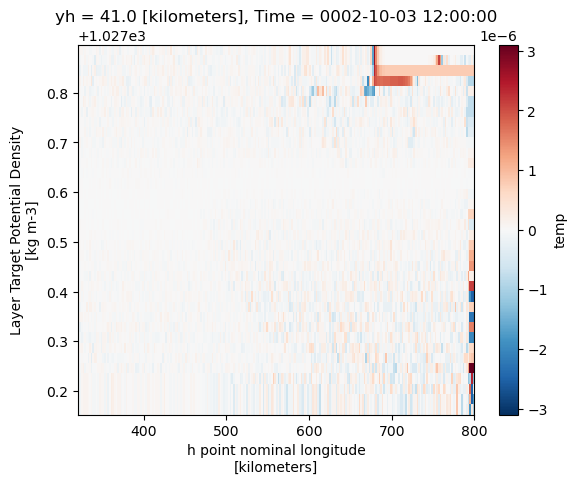

<xarray.DataArray 'melt' ()>
array(2.86102295e-06)
Coordinates:
    time     object 0002-10-03 00:00:00
<xarray.DataArray 'melt' ()>
array(-4.76837158e-06)
Coordinates:
    time     object 0002-10-03 00:00:00


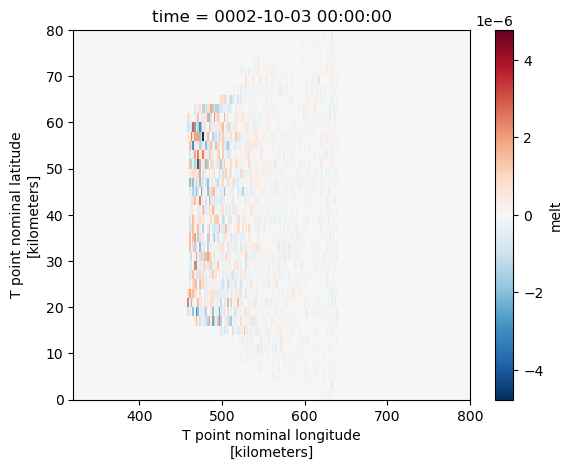

<xarray.DataArray 'umo' ()>
array(2.)
Coordinates:
    time     object 0002-10-01 04:00:00
<xarray.DataArray 'umo' ()>
array(-2.)
Coordinates:
    time     object 0002-10-01 04:00:00


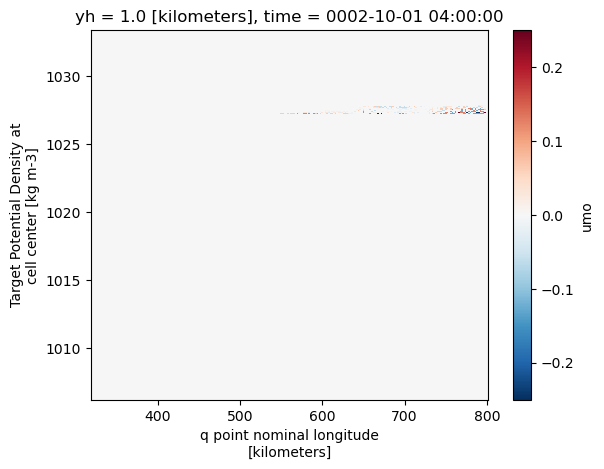

In [53]:
print(np.max(temp1-temp2))
print(np.min(temp1-temp2))

(temp1-temp2).isel(yh = 20).plot()
plt.show()

print(np.max(melt1-melt2))
print(np.min(melt1-melt2))

(melt1-melt2).plot()
plt.show()

print(np.max(umo1 - umo2))
print(np.min(umo1 - umo2))

(umo1 - umo2).isel(yh = 0).plot()
plt.show()


The difference is just floating point noise, changing the number of days in the `.sel()` makes it not noise but actual signal. So confident `ncra` did the right thing.

New file sizes: prog goes from 3.8GB to 11MB, ocean_daily_z from 9.1GB to 13MB, ocean_month_rho from 280MB to 12MB

Additionally, ISOMIP_IC is 41M and ocean_geometry is 1.5MB. Total 79MB per model.

Commands for MOM6 ISOMIP models, in folder `output000`:

```
ncra -d time,550,729 ocean_daily_z.nc ocean_daily_z_steadymean.nc
ncra -d Time,185,364 prog__0002_002.nc prog_steadymean.nc
ncra -d time,18,23 ocean_month_rho2.nc ocean_month_rho2_steadymean.nc
```

Commands for MITgcm ISOMIP models, in folder `output001`:
```
ncra -d T,185,364 shelfsnap.nc shelfsnap_steadymean.nc
ncra -d T,185,364 shelfice_tave.nc shelfice_tave_steadymean.nc
ncra -d T,185,364 tave.nc tave_steadymean.nc
 
```
combined with `grid.nc` in `output000` new file size is 37MB per model

**Need to rerun MITgcm models with correct temp and salt advection, because I didn't sync that version to data :(** 
- [x] done

**Script to repeat in all folders**
- [x] done - see  `submit_ncratimemeans-mitgcm.sh`, `ncratimemeans-mitgcm.sh`,`submit_ncratimemeans.sh`,  `ncratimemeans.sh`



Next

- **Save overturning in density space manually**

- **Do PIG results manually since not in netcdf format. Don't forget metadata.**

- **Manually save netcdfs of the MOM6 tidal velocities for supplementary: though I already saved txt files.**